## MatPlotLib

Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. It's widely used for generating plots, charts, histograms, and other graphical representations of data.

* Bar charts are suitable for comparing categories of data. Each bar represents a category, and the height or length of the bar corresponds to the value it represents.
* Pie charts display the proportion of each category in a dataset as slices of a circle. They are suitable for showing parts of a whole.
* Scatter plots visualize relationships between two continuous varaibles.
* Box plots display data distribution, highlighting percentiles and outliers for effective analysis.
* Violin plots enhance box plots by showing data concentration through probability density functions.
* Histograms represent data distribution and help identify normality or anomalies in datasets.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel("/content/drive/MyDrive/Original_Bikeshare_dataset.xlsx")
print (df.head())

        ID          Start Time            End Time  Trip Duration  \
0  5688089 2017-06-11 14:55:05 2017-06-11 15:08:21            795   
1  4096714 2017-05-11 15:30:11 2017-05-11 15:41:43            692   
2  2173887 2017-03-29 13:26:26 2017-03-29 13:48:31           1325   
3  3945638 2017-05-08 19:47:18 2017-05-08 19:59:01            703   
4  6208972 2017-06-21 07:49:16 2017-06-21 07:54:46            329   

             Start Station             End Station   User Type  Gender  \
0  Suffolk St & Stanton St  W Broadway & Spring St  Subscriber    Male   
1  Lexington Ave & E 63 St         1 Ave & E 78 St  Subscriber    Male   
2        1 Pl & Clinton St    Henry St & Degraw St  Subscriber    Male   
3    Barrow St & Hudson St         W 20 St & 8 Ave  Subscriber  Female   
4          1 Ave & E 44 St         E 53 St & 3 Ave  Subscriber    Male   

   Birth Year   Age  
0      1998.0  25.0  
1      1981.0  42.0  
2      1987.0  36.0  
3      1986.0  37.0  
4      1992.0  31.0  


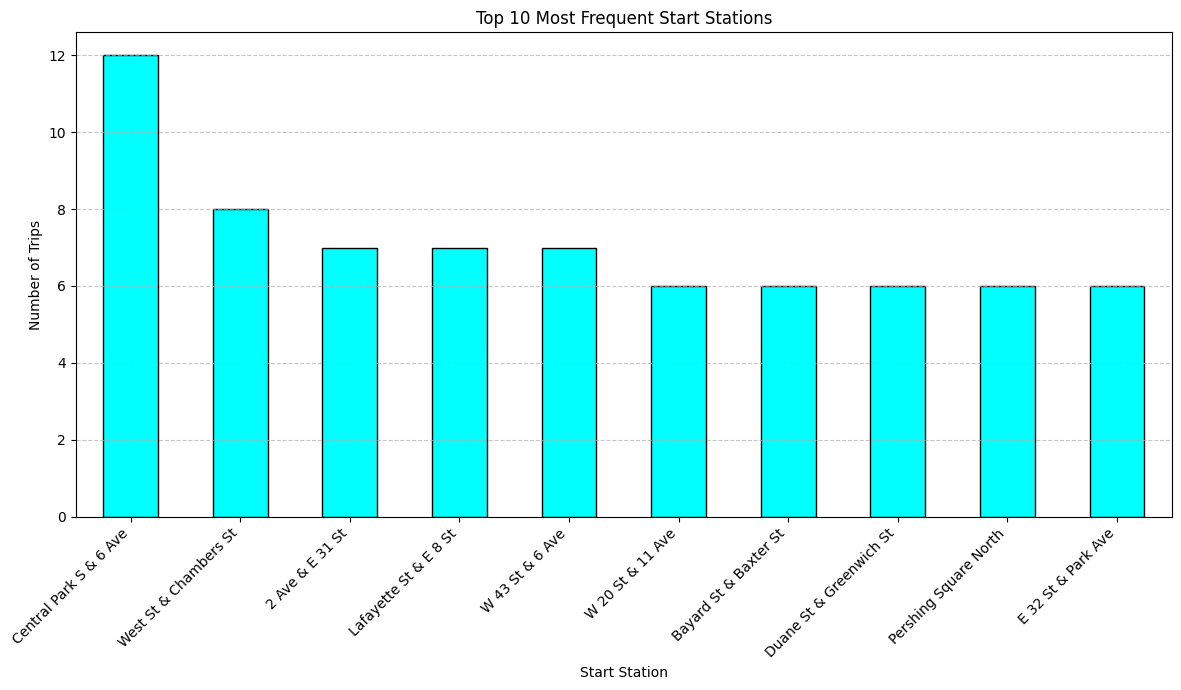

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("/content/drive/MyDrive/Original_Bikeshare_dataset.xlsx")

# Bar Chart of Top 10 Start Stations
plt.figure(figsize=(12, 7))
top_10_stations = df['Start Station'].value_counts().head(10)
top_10_stations.plot(kind='bar', color='cyan', edgecolor='black')
plt.title('Top 10 Most Frequent Start Stations')
plt.xlabel('Start Station')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

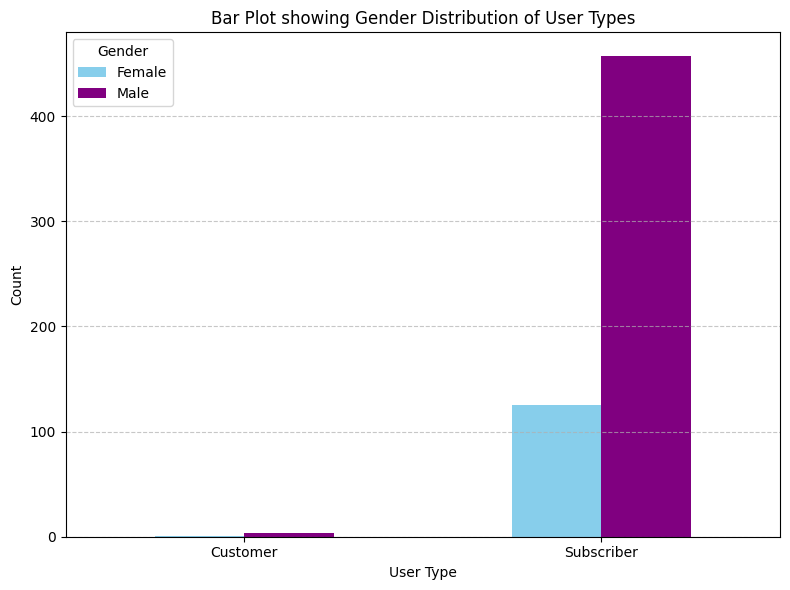

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/Original_Bikeshare_dataset.xlsx")

# Bar Plot showing Gender Distribution of User Types
X = df.Gender
y = df['User Type']

# Group by 'User Type' and 'Gender' and count occurrences
gender_user_type_counts = df.groupby(['User Type', 'Gender']).size().unstack(fill_value=0)

# Plotting with Matplotlib
gender_user_type_counts.plot(kind='bar', figsize=(8, 6), color=['skyblue', 'purple'])
plt.title('Bar Plot showing Gender Distribution of User Types')
plt.xlabel('User Type')
plt.ylabel('Count')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

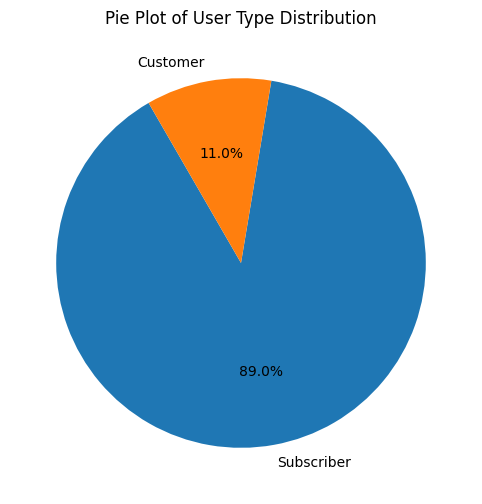

In [30]:
# Pie Plot showing User Type Distribution
plt.figure(figsize=(8, 6))

# Calculate the counts of each 'User Type'
user_type_counts = df['User Type'].value_counts()

# Plot the pie chart using the counts and their labels
plt.pie(user_type_counts.values, labels=user_type_counts.index, autopct='%1.1f%%', startangle=120)
plt.title('Pie Plot of User Type Distribution')
plt.show()

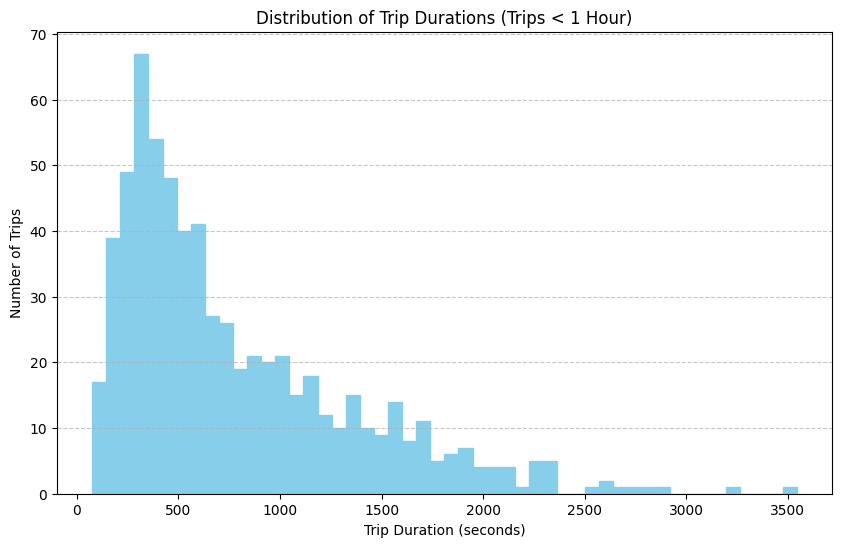

In [40]:
# histogram showing the distribution of Trip Duration in seconds
plt.figure(figsize=(10, 6))
# Filter out extremely long trips for better visualization, e.g., trips longer than 3600 seconds (1 hour)
df_filtered_duration = df[df['Trip Duration'] < 3600]
plt.hist(df_filtered_duration['Trip Duration'], bins=50, color='skyblue', edgecolor='skyblue')
plt.title('Distribution of Trip Durations (Trips < 1 Hour)')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

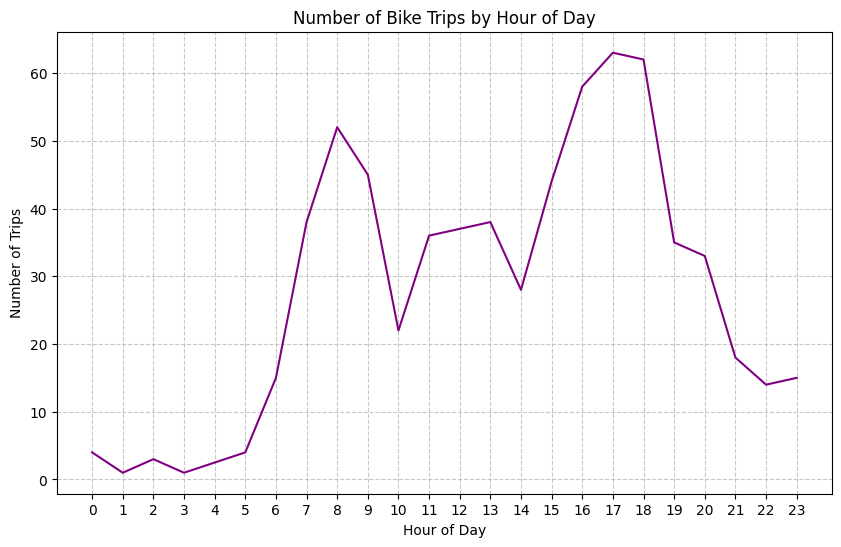

In [50]:
# line plot showing how the number of trips changes throughout the day
# Ensure 'Start Time' is in datetime format
df['Start Time'] = pd.to_datetime(df['Start Time'])

# Extract the hour from 'Start Time'
df['Start Hour'] = df['Start Time'].dt.hour

# Count trips per hour
hourly_trip_counts = df['Start Hour'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
hourly_trip_counts.plot(kind='line', marker=' ', color='purple')
plt.title('Number of Bike Trips by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24)) # Ensure all hours are shown on the x-axis
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

## **Seaborn**

Seaborn is a powerful Python data visualization library based on Matplotlib that provides a high-level interface for drawing attractive and informative statistical graphics

* A pairplot is useful for visualizing the distribution of data and relationships between variables.
The pairplot function in Seaborn, by default, creates scatterplots for all pairwise relationships between numerical columns and histograms for each numerical column's distribution.
* Dist plot helps us to check the distribution of the columns feature
* A heatmap displays data in a matrix format, using color to represent values. It's often used for correlation matrices.
* A boxplot displays the distribution of data based on a five-number summary (minimum, first quartile, median, third quartile, and maximum).
* A bar plot is a plot that represents data with rectangular bars where the length of each bar is proportional to the value it represents.
* A joint plot allows to study the relationship between 2 numeric variables. The central chart display their correlation, it is usually a hexbin plot, a 2D histogram or a 2D density plot.
* A countplot is a type of bar plot that displays the counts of observations in each categorical bin using bars. It is particularly useful for visualizing the distribution of a categorical variable.

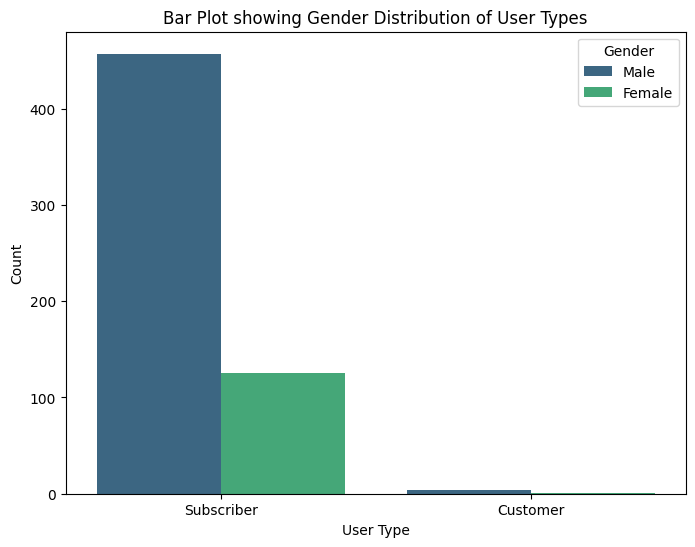

In [24]:
import seaborn as sns
X = df.Gender
y = df.Age
target_names = df['User Type']

plt.figure(figsize=(8, 6))

# Create a count plot using seaborn for Gender distribution across User Types
sns.countplot(data=df, x='User Type', hue='Gender', palette='viridis')

# Set title and labels
plt.title('Bar Plot showing Gender Distribution of User Types')
plt.xlabel('User Type')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

In [52]:
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


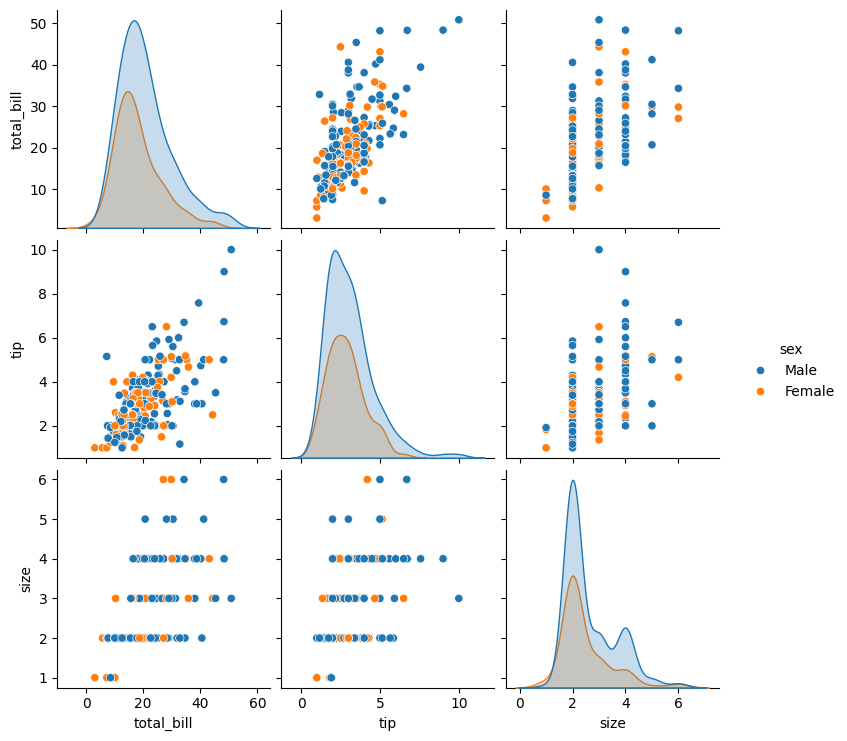

In [53]:
# Pairplot
sns.pairplot(df,hue='sex')
plt.show()

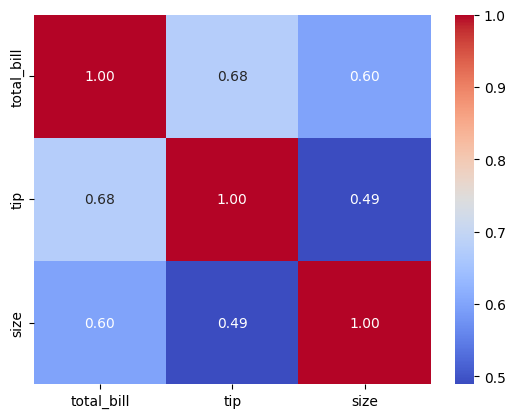

In [54]:
# Compute the correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

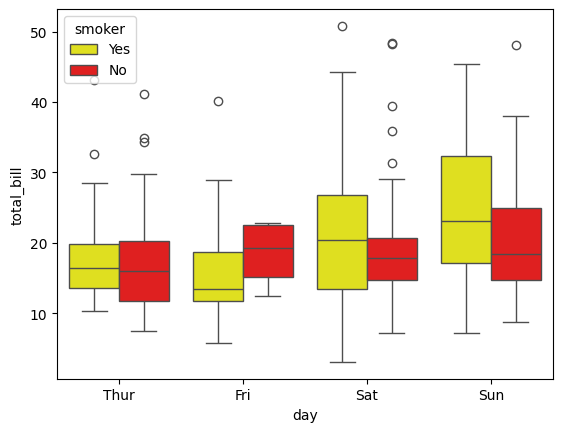

In [55]:
# Boxplot
sns.boxplot(x='day', y='total_bill',hue='smoker', data=df,palette=['yellow', 'red'])
plt.show()

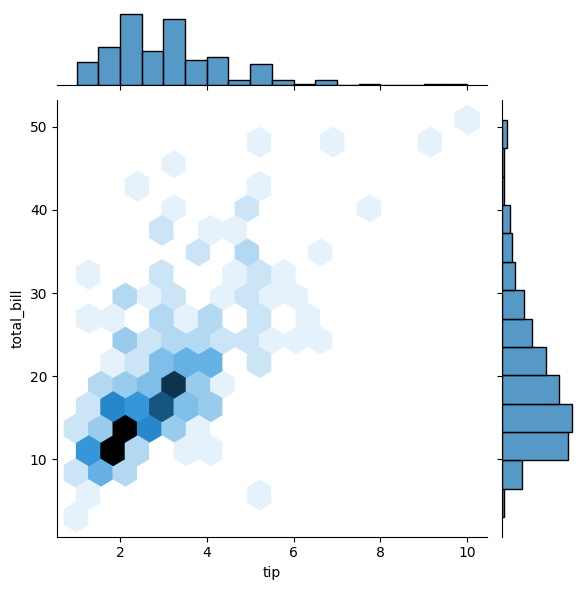

In [56]:
# Joint plot
sns.jointplot(x='tip', y='total_bill', data=df, kind='hex')
plt.show()

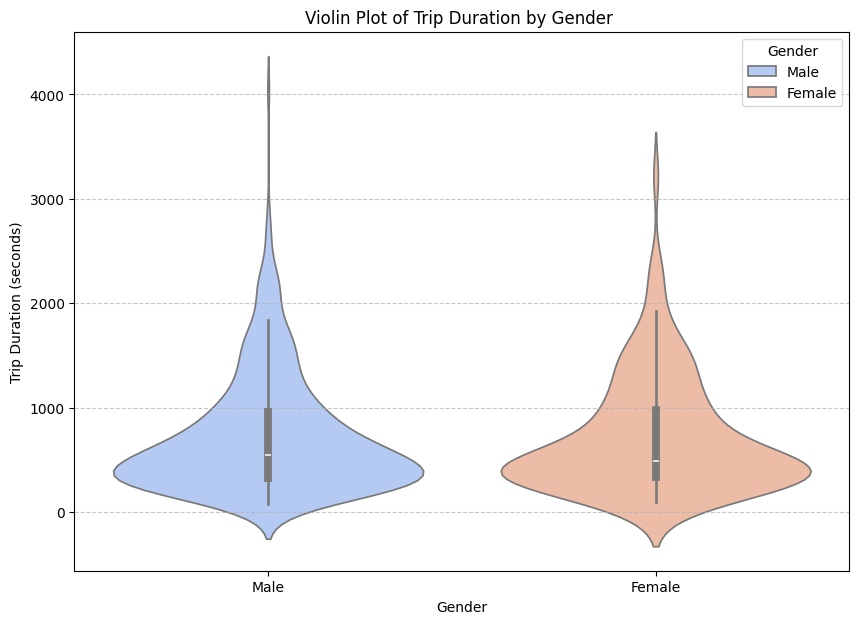

In [72]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_excel("/content/drive/MyDrive/Original_Bikeshare_dataset.xlsx")

plt.figure(figsize=(10, 7))
sns.violinplot(x='Gender', y='Trip Duration', data=df, palette='coolwarm', hue='Gender', legend=True)
plt.title('Violin Plot of Trip Duration by Gender ')
plt.xlabel('Gender')
plt.ylabel('Trip Duration (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()